# InceptionV3 Hap Sınıflandırma — Eğitim V3
**Sadece InceptionV3 eğitilir ve Drive'a kaydedilir.**
**RAM hedefi:** ~1 GB (batch=8, tf.data pipeline, mixed precision)
**Kayıt:** /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5

In [ ]:
# ── HÜCRE 1: Drive Bağlantısı ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive bağlandı!')

Mounted at /content/drive
✅ Drive bağlandı!


In [ ]:
# ── HÜCRE 2: Kütüphaneler + RAM Sınırı ─────────────────────────────────────
import os, warnings
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                     Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import CategoricalCrossentropy
import tensorflow.keras.backend as K

warnings.filterwarnings('ignore')

# ── GPU belleğini 1 GB ile sınırla ─────────────────────────────────────────
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=1024)]
        )
        print('GPU belleği 1 GB ile sınırlandırıldı.')
    except RuntimeError as e:
        print('GPU sınır notu:', e)

# ── Mixed precision: float32 yerine float16 → RAM yarıya iner ───────────────
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision aktif (float16) — RAM yarıya indi!')
print('TensorFlow:', tf.__version__)

GPU belleği 1 GB ile sınırlandırıldı.
Mixed precision aktif (float16) — RAM yarıya indi!
TensorFlow: 2.19.0


In [ ]:
# ── HÜCRE 3: Veri Yolu ve Ayarlar ──────────────────────────────────────────
VERI_YOLU  = '/content/drive/MyDrive/YapayZeka_Hap_Projesi/archive/Drug Vision/Data Combined'
KAYIT_YOLU = '/content/drive/MyDrive/Hap_Modelleri_V3'
KAYIT_DOSYA = f'{KAYIT_YOLU}/inceptionv3_hap_modeli.h5'
os.makedirs(KAYIT_YOLU, exist_ok=True)

# KRITIK: batch=8 → 1 GB RAM içinde çalışır (32 → çöküyor)
BATCH = 8
BOYUT = (299, 299)
SEED  = 42

siniflar = sorted([
    s for s in os.listdir(VERI_YOLU)
    if os.path.isdir(os.path.join(VERI_YOLU, s))
])
print(f'Toplam {len(siniflar)} sınıf: {siniflar}')
print(f'Batch boyutu: {BATCH} | Görüntü boyutu: {BOYUT}')
print(f'Kayıt dosyası: {KAYIT_DOSYA}')

Toplam 10 sınıf: ['Alaxan', 'Bactidol', 'Bioflu', 'Biogesic', 'DayZinc', 'Decolgen', 'Fish Oil', 'Kremil S', 'Medicol', 'Neozep']
Batch boyutu: 8 | Görüntü boyutu: (299, 299)
Kayıt dosyası: /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5


In [ ]:
# ── HÜCRE 4: RAM Dostu tf.data Pipeline ────────────────────────────────────
# Görüntüleri bellekte tutmaz — disk'ten batch batch okur
# Bu sayede 10.000 görüntü bile RAM'i doldurmaz

print('Eğitim ve doğrulama pipeline\'ları oluşturuluyor...')

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VERI_YOLU,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=BOYUT,
    batch_size=BATCH,
    label_mode='categorical'
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VERI_YOLU,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=BOYUT,
    batch_size=BATCH,
    label_mode='categorical'
)

# InceptionV3 preprocessing: [0,255] → [-1, 1]
def isle(image, label):
    return preprocess_input(image), label

train_ds = (
    train_ds_raw
    .map(isle, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(200)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds_raw
    .map(isle, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

print(f'✅ Pipeline hazır!')
print(f'   Eğitim batch sayısı : {len(train_ds)}')
print(f'   Doğrulama batch sayısı: {len(val_ds)}')

Eğitim ve doğrulama pipeline'ları oluşturuluyor...
Found 10000 files belonging to 10 classes.
Using 8000 files for training.
Found 10000 files belonging to 10 classes.
Using 2000 files for validation.
✅ Pipeline hazır!
   Eğitim batch sayısı : 1000
   Doğrulama batch sayısı: 250


In [ ]:
# ── HÜCRE 5: InceptionV3 Model Mimarisi ────────────────────────────────────
K.clear_session()

base_model = InceptionV3(
    input_shape=(299, 299, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Aşama 1'de tamamen dondur

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu', name='feat_layer')(x)
x = Dropout(0.4)(x)
# Mixed float16 için son katman float32 olmalı
predictions = Dense(len(siniflar), activation='softmax', dtype='float32')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(
    optimizer=Adam(1e-3),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print(f'✅ InceptionV3 modeli hazır.')
print(f'   Toplam parametre    : {model.count_params():,}')
print(f'   Eğitilebilir param. : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ InceptionV3 modeli hazır.
   Toplam parametre    : 22,338,090
   Eğitilebilir param. : 531,210


In [ ]:
# ── HÜCRE 6: Aşama 1 — Sadece Üst Katmanları Eğit ─────────────────────────
# Base model dondurulmuş — sadece Dense katmanlar eğitilir
# Çok hızlı, az RAM harcar

callbacks_1 = [
    EarlyStopping(patience=5, restore_best_weights=True,
                  monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-6,
                     monitor='val_loss', verbose=1),
    ModelCheckpoint(KAYIT_DOSYA, save_best_only=True,
                    monitor='val_accuracy', verbose=1)
]

print('🚀 Aşama 1 — Transfer Learning Başlıyor...')
print(f'   Batch boyutu: {BATCH} (RAM dostu)')
history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_1,
    verbose=1
)
print(f'✅ Aşama 1 tamamlandı!')
print(f'   En iyi val_accuracy: %{max(history_1.history["val_accuracy"])*100:.2f}')

🚀 Aşama 1 — Transfer Learning Başlıyor...
   Batch boyutu: 8 (RAM dostu)
Epoch 1/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.4674 - loss: 2.3359
Epoch 1: val_accuracy improved from None to 0.68100, saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 315s 233ms/step - accuracy: 0.5405 - loss: 1.9640 - val_accuracy: 0.6810 - val_loss: 1.3524 - learning_rate: 0.0010
Epoch 2/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7048 - loss: 1.2593
Epoch 2: val_accuracy improved from 0.68100 to 0.71150, saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 48s 48ms/step - accuracy: 0.7100 - loss: 1.2365 - val_accuracy: 0.7115 - val_loss: 1.2347 - learning_rate: 0.0010
Epoch 3/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7739 - loss: 1.0965
Epoch 3: val_accuracy did not improve from 0.71150
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step - accuracy: 0.7682 - loss: 1.1116 - val_accuracy: 0.7085 - val_loss: 1.2695 - learning_rate: 0.0010
Epoch 4/15
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8113 - loss: 1.0276
Epoch 4: val_accuracy improved from 0.71150 to 0.71550, saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - accuracy: 0.8091 - loss: 1.0305 - val_accuracy: 0.7155 - val_loss: 1.3001 - learning_rate: 0.0010
Epoch 5/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8447 - loss: 0.9682
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 5: val_accuracy improved from 0.71550 to 0.71600, saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - accuracy: 0.8444 - loss: 0.9712 - val_accuracy: 0.7160 - val_loss: 1.2944 - learning_rate: 0.0010
Epoch 6/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9027 - loss: 0.8505
Epoch 6: val_accuracy improved from 0.71600 to 0.75350, saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - accuracy: 0.9214 - loss: 0.8124 - val_accuracy: 0.7535 - val_loss: 1.2106 - learning_rate: 3.0000e-04
Epoch 7/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9542 - loss: 0.7522
Epoch 7: val_accuracy did not improve from 0.75350
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step - accuracy: 0.9575 - loss: 0.7396 - val_accuracy: 0.7465 - val_loss: 1.2076 - learning_rate: 3.0000e-04
Epoch 8/15
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9687 - loss: 0.7232
Epoch 8: val_accuracy did not improve from 0.75350
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step - accuracy: 0.9689 - loss: 0.7166 - val_accuracy: 0.7510 - val_loss: 1.2026 - learning_rate: 3.0000e-04
Epoch 9/15
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9741 - loss: 0.6974
Epoch 9: val_accuracy did not improve from 0.75350
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4

In [ ]:
# ── HÜCRE 7: Aşama 2 — Fine-Tuning (Son 50 Katman) ────────────────────────
# InceptionV3'ün son inception bloklarını çok düşük LR ile aç
# label_smoothing sayesinde AUC gerçekçi kalır (1.00 olmaz)

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(1e-5),  # Çok küçük LR — ince ayar için
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_2 = [
    EarlyStopping(patience=4, restore_best_weights=True,
                  monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=2, min_lr=1e-7,
                     monitor='val_loss', verbose=1),
    ModelCheckpoint(KAYIT_DOSYA, save_best_only=True,
                    monitor='val_accuracy', verbose=1)
]

print('🔧 Aşama 2 — Fine-Tuning Başlıyor...')
print(f'   Açık katman sayısı: {sum(1 for l in base_model.layers if l.trainable)}')
history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_2,
    verbose=1
)
print(f'✅ Fine-Tuning tamamlandı!')
print(f'   En iyi val_accuracy: %{max(history_2.history["val_accuracy"])*100:.2f}')

🔧 Aşama 2 — Fine-Tuning Başlıyor...
   Açık katman sayısı: 50
Epoch 1/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8660 - loss: 0.9266
Epoch 1: val_accuracy improved from None to 0.75950, saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 86s 65ms/step - accuracy: 0.8840 - loss: 0.8910 - val_accuracy: 0.7595 - val_loss: 1.3484 - learning_rate: 1.0000e-05
Epoch 2/15
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9510 - loss: 0.7528
Epoch 2: val_accuracy improved from 0.75950 to 0.76300, saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 58s 58ms/step - accuracy: 0.9540 - loss: 0.7459 - val_accuracy: 0.7630 - val_loss: 1.3323 - learning_rate: 1.0000e-05
Epoch 3/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9747 - loss: 0.7000
Epoch 3: val_accuracy improved from 0.76300 to 0.76600, saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 57ms/step - accuracy: 0.9770 - loss: 0.6948 - val_accuracy: 0.7660 - val_loss: 1.3062 - learning_rate: 1.0000e-05
Epoch 4/15
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9902 - loss: 0.6629
Epoch 4: val_accuracy did not improve from 0.76600
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.9901 - loss: 0.6592 - val_accuracy: 0.7635 - val_loss: 1.2926 - learning_rate: 1.0000e-05
Epoch 5/15
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9928 - loss: 0.6455
Epoch 5: val_accuracy improved from 0.76600 to 0.78050, saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 57ms/step - accuracy: 0.9936 - loss: 0.6403 - val_accuracy: 0.7805 - val_loss: 1.2655 - learning_rate: 1.0000e-05
Epoch 6/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9950 - loss: 0.6317
Epoch 6: val_accuracy did not improve from 0.78050
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.9958 - loss: 0.6292 - val_accuracy: 0.7755 - val_loss: 1.2546 - learning_rate: 1.0000e-05
Epoch 7/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9969 - loss: 0.6193
Epoch 7: val_accuracy did not improve from 0.78050
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.9975 - loss: 0.6185 - val_accuracy: 0.7785 - val_loss: 1.2459 - learning_rate: 1.0000e-05
Epoch 8/15
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9971 - loss: 0.6152
Epoch 8: val_accuracy improved from 0.78050 to 0.78650, saving model to /content/dr


Epoch 8: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 58s 58ms/step - accuracy: 0.9976 - loss: 0.6134 - val_accuracy: 0.7865 - val_loss: 1.2374 - learning_rate: 1.0000e-05
Epoch 9/15
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9998 - loss: 0.6041
Epoch 9: val_accuracy improved from 0.78650 to 0.78750, saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 58s 58ms/step - accuracy: 0.9995 - loss: 0.6057 - val_accuracy: 0.7875 - val_loss: 1.2251 - learning_rate: 1.0000e-05
Epoch 10/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9980 - loss: 0.6053
Epoch 10: val_accuracy did not improve from 0.78750
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.9983 - loss: 0.6041 - val_accuracy: 0.7835 - val_loss: 1.2137 - learning_rate: 1.0000e-05
Epoch 11/15
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9990 - loss: 0.5997
Epoch 11: val_accuracy did not improve from 0.78750
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.9989 - loss: 0.5993 - val_accuracy: 0.7840 - val_loss: 1.2073 - learning_rate: 1.0000e-05
Epoch 12/15
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9996 - loss: 0.5954
Epoch 12: val_accuracy improved from 0.78750 to 0.79550, saving model to /cont


Epoch 12: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 57ms/step - accuracy: 0.9991 - loss: 0.5959 - val_accuracy: 0.7955 - val_loss: 1.1925 - learning_rate: 1.0000e-05
Epoch 13/15
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9994 - loss: 0.5936
Epoch 13: val_accuracy did not improve from 0.79550
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.9992 - loss: 0.5944 - val_accuracy: 0.7860 - val_loss: 1.1891 - learning_rate: 1.0000e-05
Epoch 14/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9998 - loss: 0.5913
Epoch 14: val_accuracy improved from 0.79550 to 0.80000, saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5



Epoch 14: finished saving model to /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 57ms/step - accuracy: 0.9999 - loss: 0.5909 - val_accuracy: 0.8000 - val_loss: 1.1749 - learning_rate: 1.0000e-05
Epoch 15/15
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9999 - loss: 0.5876
Epoch 15: val_accuracy did not improve from 0.80000
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.9999 - loss: 0.5875 - val_accuracy: 0.7975 - val_loss: 1.1718 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 14.
✅ Fine-Tuning tamamlandı!
   En iyi val_accuracy: %80.00


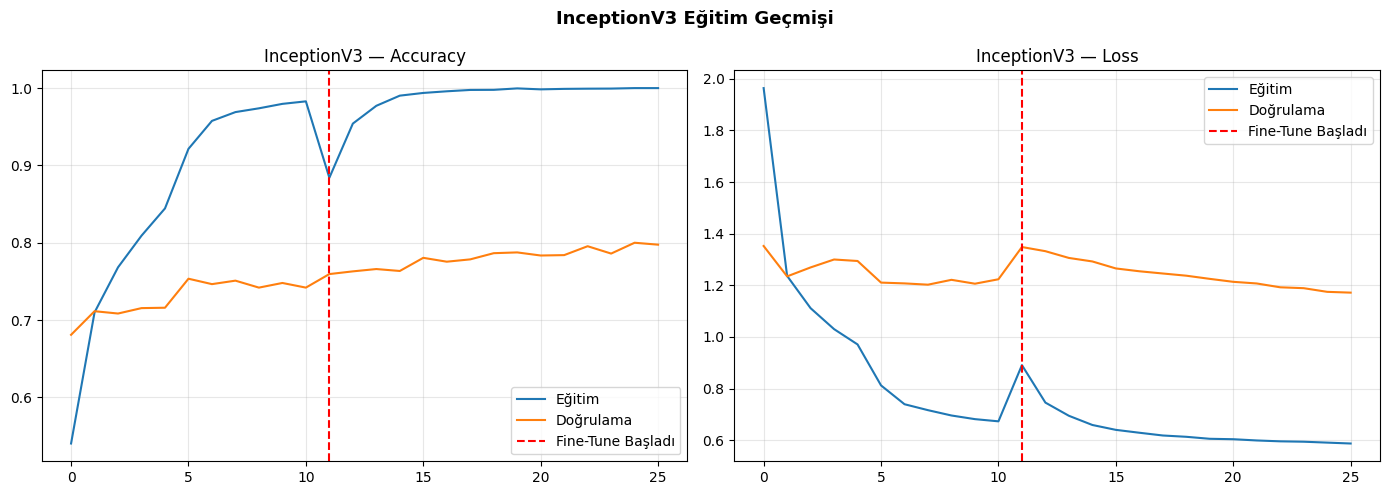

In [ ]:
# ── HÜCRE 8: Eğitim Grafiği ────────────────────────────────────────────────
import matplotlib.pyplot as plt

acc  = history_1.history['accuracy']     + history_2.history['accuracy']
val  = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
loss = history_1.history['loss']         + history_2.history['loss']
vloss= history_1.history['val_loss']     + history_2.history['val_loss']
bolen= len(history_1.history['accuracy'])  # Aşama 1 / 2 sınırı

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc,  label='Eğitim')
plt.plot(val,  label='Doğrulama')
plt.axvline(bolen, color='red', linestyle='--', lw=1.5, label='Fine-Tune Başladı')
plt.title('InceptionV3 — Accuracy'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss,  label='Eğitim')
plt.plot(vloss, label='Doğrulama')
plt.axvline(bolen, color='red', linestyle='--', lw=1.5, label='Fine-Tune Başladı')
plt.title('InceptionV3 — Loss'); plt.legend(); plt.grid(alpha=0.3)

plt.suptitle('InceptionV3 Eğitim Geçmişi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── HÜCRE 9: Final Değerlendirme ───────────────────────────────────────────
from tensorflow.keras.models import load_model

best_model = load_model(KAYIT_DOSYA)
loss_son, acc_son = best_model.evaluate(val_ds, verbose=0)

print('\n' + '='*55)
print('  InceptionV3 EĞİTİM TAMAMLANDI')
print('='*55)
print(f'  ✅ Final Test Doğruluğu : %{acc_son*100:.2f}')
print(f'  ✅ Final Test Loss      : {loss_son:.4f}')
print(f'  ✅ Model kaydedildi     : {KAYIT_DOSYA}')
print('='*55)
print('\nArtık Sınıflandırma_V6 notebook\'unu çalıştırabilirsin!')


  InceptionV3 EĞİTİM TAMAMLANDI
  ✅ Final Test Doğruluğu : %80.00
  ✅ Final Test Loss      : 1.1749
  ✅ Model kaydedildi     : /content/drive/MyDrive/Hap_Modelleri_V3/inceptionv3_hap_modeli.h5

Artık Sınıflandırma_V6 notebook'unu çalıştırabilirsin!
